# Worked solution: the warden's mess, with numbers

Week 0, weekend project. This is one complete run through the eight steps of the brief, with a check
under every step that proves the number the brief promised. Try every step yourself before reading
this.

In [1]:
import pathlib
import sys

here = pathlib.Path.cwd().resolve()
root = next(p for p in [here, *here.parents] if (p / "scripts" / "c2kit.py").exists())
sys.path.insert(0, str(root / "scripts"))
import c2kit as kit

# Thursday's database is the library one you made from the setup sheet, reached as your own user.
kit.WAREHOUSE.clear()
kit.WAREHOUSE.update(dbname="library")

import math

kit.flow(["load", "eaten and wasted", "by weekday", "in SQL", "the cost", "a rule", "a margin"], title="The seven computed steps, then the page")

## Step 1. Load the register

The data file sits in the day's `data/` folder, one dictionary per night.

In [2]:
nights = kit.load_records("C2_W00_D04_mess_log_STUDENT.py")
cooked = sum(n["cooked"] for n in nights)
print(len(nights), "nights,", cooked, "plates cooked")
kit.check("28 nights and 6,720 plates cooked", len(nights) == 28 and cooked == 6720)

28 nights, 6720 plates cooked


## Step 2. Eaten and wasted

In [3]:
eaten = sum(n["eaten"] for n in nights)
wasted = cooked - eaten
share = round(wasted / cooked * 100, 1)
print(eaten, "eaten,", wasted, "wasted,", share, "percent of what was cooked")
kit.check("5,230 eaten, 1,490 wasted, 22.2 percent", (eaten, wasted, share) == (5230, 1490, 22.2))

5230 eaten, 1490 wasted, 22.2 percent of what was cooked


The warden's "about a fifth" was close: the register says 22.2 percent.

## Step 3. Waste by weekday, in Python

In [4]:
waste_by_day = {}
for n in nights:
    day = n["weekday"]
    if day not in waste_by_day:
        waste_by_day[day] = 0
    waste_by_day[day] = waste_by_day[day] + (n["cooked"] - n["eaten"])

ranked = sorted(waste_by_day.items(), key=lambda item: item[1], reverse=True)
kit.table(["weekday", "plates wasted"], ranked, caption="Four weeks of waste, by weekday")
weekend = waste_by_day["Fri"] + waste_by_day["Sat"] + waste_by_day["Sun"]
print("Friday to Sunday:", weekend, "plates,", round(weekend / wasted * 100), "percent of the waste")
kit.check("Saturday wastes most, 360 plates", ranked[0] == ("Sat", 360))
kit.check("Friday to Sunday waste 942 plates", weekend == 942)

weekday,plates wasted
Sat,360
Sun,322
Fri,260
Thu,160
Mon,139
Wed,129
Tue,120


Friday to Sunday: 942 plates, 63 percent of the waste


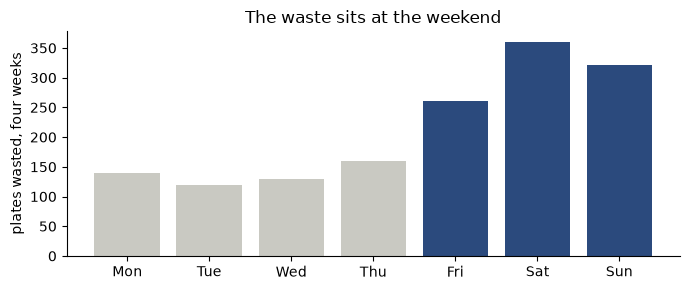

In [5]:
import matplotlib.pyplot as plt

order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(order, [waste_by_day[d] for d in order], color=[kit.ACCENT if d in ("Fri", "Sat", "Sun") else kit.LINE for d in order])
ax.set_ylabel("plates wasted, four weeks")
ax.set_title("The waste sits at the weekend")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## Step 4. The same breakdown, in SQL

The setup file builds the `dinners` table. The cell looks for it beside this notebook first, then in
the day's `sql/` folder. The helper's query function never commits, so the load runs on its own
connection with autocommit on.

In [6]:
name = "C2_W00_D04_03_mess_setup_STUDENT.sql"
candidates = [here / name] + [p / "sql" / name for p in [here, *here.parents]]
setup = next(p for p in candidates if p.is_file()).read_text()
conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(setup)
conn.close()

rows = kit.sql("""
    SELECT weekday, SUM(cooked - eaten) AS wasted
    FROM dinners
    GROUP BY weekday
    ORDER BY wasted DESC
""")
kit.table(["weekday", "plates wasted"], [(r["weekday"], r["wasted"]) for r in rows],
          caption="The same breakdown, from Postgres")
kit.check("SQL and Python agree on all seven weekdays",
          {r["weekday"]: r["wasted"] for r in rows} == waste_by_day)

weekday,plates wasted
Sat,360
Sun,322
Fri,260
Thu,160
Mon,139
Wed,129
Tue,120


## Step 5. What the waste costs

The Rs 40 a plate is invented for the project.

In [7]:
price = 40
bill = cooked * price
thrown = wasted * price
print(f"Bill: {kit.rupees(bill)}; spent on plates nobody ate: {kit.rupees(thrown)}")
kit.check("a bill of Rs 2,68,800, of which Rs 59,600 was wasted", (bill, thrown) == (268800, 59600))

Bill: Rs 2,68,800; spent on plates nobody ate: Rs 59,600


## Step 6. A rule with no model, without a margin

Each night of weeks 2 to 4, cook the average eaten on the same weekday in the earlier weeks, rounded
up. The function returns what the rule cooks, what it wastes, and how short it falls.

In [8]:
def test_rule(margin):
    wasted_by_rule, short_nights, short_plates, cooked_by_rule = 0, 0, 0, 0
    for n in nights:
        if n["week"] == 1:
            continue
        earlier = [m["eaten"] for m in nights if m["weekday"] == n["weekday"] and m["week"] < n["week"]]
        plan = math.ceil(sum(earlier) / len(earlier) * margin)
        cooked_by_rule += plan
        if plan >= n["eaten"]:
            wasted_by_rule += plan - n["eaten"]
        else:
            short_nights += 1
            short_plates += n["eaten"] - plan
    return wasted_by_rule, short_nights, short_plates, cooked_by_rule


w0, short0, plates0, _ = test_rule(1.00)
print(short0, "of 21 nights short, by", plates0, "plates in all")
kit.check("without a margin, 11 nights come up short by 28 plates", (short0, plates0) == (11, 28))

11 of 21 nights short, by 28 plates in all


Eleven of twenty-one nights without enough dinner is the failure worth remembering: an average is
exceeded about half the time, so a rule that cooks exactly the average leaves students hungry about
half the time.

## Step 7. The same rule with a 5 percent margin

In [9]:
w5, short5, plates5, cooked5 = test_rule(1.05)
status_quo = sum(n["cooked"] - n["eaten"] for n in nights if n["week"] > 1)
print("waste with the rule:", w5, " waste cooking for all 240:", status_quo, " short nights:", short5)
print("fewer plates wasted:", status_quo - w5, "which is", round((status_quo - w5) / status_quo * 100), "percent less")
kit.check("with a 5 percent margin, no night comes up short", short5 == 0)
kit.check("waste falls from 1,116 to 202 plates over weeks 2 to 4", (status_quo, w5) == (1116, 202))

kit.side_by_side(
    kit.stack(["cook for all 240", "1,116 plates wasted", "no night short"], lit=1,
              title="Weeks 2 to 4, as the mess runs today", show=False),
    kit.stack(["the weekday rule plus 5 percent", "202 plates wasted", "no night short"], lit=1,
              title="Weeks 2 to 4, with the rule", show=False),
)

waste with the rule: 202  waste cooking for all 240: 1116  short nights: 0
fewer plates wasted: 914 which is 82 percent less


## Step 8. One page for the warden, as one strong version

**The problem.** You asked for an app that predicts how many students will eat. Underneath, the mess
orders dinner for all 240 students every night because it has no signal of who is coming, and the
vendor bills for every plate.

**The number.** Over four weeks the mess cooked 6,720 plates and 5,230 were eaten, so 1,490 were thrown
away, 22.2 percent. At Rs 40 a plate that is Rs 59,600 of a Rs 2,68,800 bill. Friday to Sunday account
for 63 percent of the waste.

**Three options.**

| Option | Cost | Time to start | What could go wrong |
|---|---|---|---|
| Cook each weekday's recent average plus 5 percent | The register and a calculator | Next Monday | An exam week or a festival breaks the pattern |
| A sign-out each morning on the mess group | One message from each student who will skip | Two weeks, once the mess committee agrees | Students forget, so the count stays too high |
| An app that predicts attendance | A build, data and someone to maintain it | Months | It costs more than the waste it saves |

**Ruled out.** The app, because the weekday rule already cut the waste over weeks 2 to 4 from 1,116
plates to 202 without one, and an app would take months and a maintainer. The sign-out on its own,
because it needs the committee's agreement and a new habit from 240 students before it saves a
single plate.

**The thinnest first version.** From next Monday the mess manager cooks each night the average of the
same weekday over the last four weeks, plus 5 percent, rounded up, and writes down the plates eaten.
After two weeks we compare the plates wasted with the same two weeks today, and we watch one other
number: any night that runs short.

**What four weeks cannot tell us.** Exam weeks, festivals, the first week of a term and a new menu all
break the weekday pattern. On those weeks the manager cooks for everyone, as today.

In [10]:
kit.check_summary()